In [1]:
import Pkg
Pkg.add("Kinbiont");
Pkg.add("SymbolicRegression");
Pkg.add("Plots");
Pkg.add("CSV");
Pkg.add("Tables");
using Kinbiont;
using SymbolicRegression;
using Plots;
using Tables;
using CSV;

   Resolving package versions...
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Project.toml`
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Manifest.toml`
   Resolving package versions...
    Updating `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Project.toml`
  [8254be44] + SymbolicRegression v1.9.0
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Manifest.toml`
   Resolving package versions...
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Project.toml`
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Manifest.toml`
   Resolving package versions...
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Project.toml`
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbi

We start setting the data and the folder path

In [5]:
path_to_data = string("../Automatic_law_detection/Monod_experiment/data/Exp_1/channel_1.csv");
path_to_annotation = string("../Automatic_law_detection/Monod_experiment/data/Exp_1/annotation.csv");
path_to_calib = string("../Automatic_law_detection/Monod_experiment/data/cal_curve_avg.csv");

We set the parameters used for the segmentation fitting

In [6]:
model1 = "HPM_exp";

lb_param1 = [0.00001, 0.000001];
ub_param1 =[0.5,       1.5];
param_guess1 =[0.01, 0.01];
    
model2 = "logistic"

lb_param2 = [0.00001, 0.000001];
ub_param2 =[0.5,       2.5,    ];
param_guess2 =[0.01, 1.01];
    

list_of_models = [model1,model2];
list_guess=  [param_guess1,param_guess2];
list_lb=  [lb_param1,lb_param2];
list_ub=  [ub_param1,ub_param2];

We fit with one change point. in this case note that "fixed_cpd=false" that means that there is the search of the best 1 change point among different candidates. 

In [7]:
fit_file =  segmentation_ODE_file(
    "seg_exp_1_calibrated", #label of the experiment
    path_to_data, # path to the folder to analyze
    list_of_models, # ode model to use 
    list_guess, #  param
    1;
    path_to_annotation=path_to_annotation,# path to the annotation of the wells
    detect_number_cpd=false,
    fixed_cpd=false,
    calibration_OD_curve=path_to_calib,
    multiple_scattering_correction=true, # if true uses the given calibration curve to fix the data
    type_of_curve="deriv",
    pt_smooth_derivative= 10,
    type_of_smoothing = "lowess",
    verbose = true,
    write_res =false,
    win_size=12, # numebr of the point to generate intial condition
    smoothing =true,
    lb_param_array=list_lb, # lower bound param
    ub_param_array=list_ub, # upper bound param
    maxiters = 200000
);

┌ Warning: Unrecognized stop reason: Too many steps (101) without any function evaluations (probably search has converged). Defaulting to ReturnCode.Default.
└ @ Optimization C:\Users\fabri\.julia\packages\Optimization\4ueet\src\utils.jl:92
┌ Warning: Unrecognized stop reason: Too many steps (101) without any function evaluations (probably search has converged). Defaulting to ReturnCode.Default.
└ @ Optimization C:\Users\fabri\.julia\packages\Optimization\4ueet\src\utils.jl:92
┌ Warning: Using arrays or dicts to store parameters of different types can hurt performance.
│ Consider using tuples instead.
└ @ SciMLBase C:\Users\fabri\.julia\packages\SciMLBase\2TYas\src\performance_warnings.jl:33
┌ Warning: Unrecognized stop reason: Too many steps (101) without any function evaluations (probably search has converged). Defaulting to ReturnCode.Default.
└ @ Optimization C:\Users\fabri\.julia\packages\Optimization\4ueet\src\utils.jl:92
┌ Warning: Unrecognized stop reason: Too many steps (101) 

the results are:
Any["seg_exp_1_calibrated" "seg_exp_1_calibrated"; "A1" "A1"; "HPM_exp" "logistic"; 0.5 0.3628324267577993; 0.1289006413323332 1.0802465695635628; 0.4939900444998214 0.12102712268104984; 0.6565356162211143 0.18928383569557117; 0.00024318438580098284 0.00024000545142514797; 1 2]


┌ Warning: Unrecognized stop reason: Too many steps (101) without any function evaluations (probably search has converged). Defaulting to ReturnCode.Default.
└ @ Optimization C:\Users\fabri\.julia\packages\Optimization\4ueet\src\utils.jl:92
┌ Warning: Unrecognized stop reason: Too many steps (101) without any function evaluations (probably search has converged). Defaulting to ReturnCode.Default.
└ @ Optimization C:\Users\fabri\.julia\packages\Optimization\4ueet\src\utils.jl:92
┌ Warning: Unrecognized stop reason: Too many steps (101) without any function evaluations (probably search has converged). Defaulting to ReturnCode.Default.
└ @ Optimization C:\Users\fabri\.julia\packages\Optimization\4ueet\src\utils.jl:92
┌ Warning: Unrecognized stop reason: Too many steps (101) without any function evaluations (probably search has converged). Defaulting to ReturnCode.Default.
└ @ Optimization C:\Users\fabri\.julia\packages\Optimization\4ueet\src\utils.jl:92
┌ Warning: Unrecognized stop reason:

the results are:
Any["seg_exp_1_calibrated" "seg_exp_1_calibrated"; "A2" "A2"; "HPM_exp" "logistic"; 0.5 0.4111441894584423; 0.14393255846310457 0.5989931152695295; 0.4867706529451389 0.17798748960223446; 0.6313543592008842 0.31186768102225226; 6.768753986011018e-5 0.0001120549068864716; 1 2]


┌ Warning: Unrecognized stop reason: Too many steps (101) without any function evaluations (probably search has converged). Defaulting to ReturnCode.Default.
└ @ Optimization C:\Users\fabri\.julia\packages\Optimization\4ueet\src\utils.jl:92
┌ Warning: Unrecognized stop reason: Too many steps (101) without any function evaluations (probably search has converged). Defaulting to ReturnCode.Default.
└ @ Optimization C:\Users\fabri\.julia\packages\Optimization\4ueet\src\utils.jl:92
┌ Warning: Unrecognized stop reason: Too many steps (101) without any function evaluations (probably search has converged). Defaulting to ReturnCode.Default.
└ @ Optimization C:\Users\fabri\.julia\packages\Optimization\4ueet\src\utils.jl:92
┌ Warning: Unrecognized stop reason: Too many steps (101) without any function evaluations (probably search has converged). Defaulting to ReturnCode.Default.
└ @ Optimization C:\Users\fabri\.julia\packages\Optimization\4ueet\src\utils.jl:92
┌ Warning: Unrecognized stop reason:

...

┌ Warning: Unrecognized stop reason: Too many steps (101) without any function evaluations (probably search has converged). Defaulting to ReturnCode.Default.
└ @ Optimization C:\Users\fabri\.julia\packages\Optimization\4ueet\src\utils.jl:92
┌ Warning: Unrecognized stop reason: Too many steps (101) without any function evaluations (probably search has converged). Defaulting to ReturnCode.Default.
└ @ Optimization C:\Users\fabri\.julia\packages\Optimization\4ueet\src\utils.jl:92
┌ Warning: Unrecognized stop reason: Too many steps (101) without any function evaluations (probably search has converged). Defaulting to ReturnCode.Default.
└ @ Optimization C:\Users\fabri\.julia\packages\Optimization\4ueet\src\utils.jl:92
┌ Warning: Unrecognized stop reason: Too many steps (101) without any function evaluations (probably search has converged). Defaulting to ReturnCode.Default.
└ @ Optimization C:\Users\fabri\.julia\packages\Optimization\4ueet\src\utils.jl:92
┌ Warning: Unrecognized stop reason:

the results are:
Any["seg_exp_1_calibrated" "seg_exp_1_calibrated"; "F6" "F6"; "HPM_exp" "logistic"; 0.3429037462878224 0.4208468520224691; 0.5163135665478868 0.05181010988900285; 0.3253809368224622 0.13478719961151686; 0.39692139370854623 0.20432839625087343; 2.1510567528636136e-7 6.408743593046219e-7; 1 2]


┌ Warning: Unrecognized stop reason: Too many steps (101) without any function evaluations (probably search has converged). Defaulting to ReturnCode.Default.
└ @ Optimization C:\Users\fabri\.julia\packages\Optimization\4ueet\src\utils.jl:92
┌ Warning: Unrecognized stop reason: Too many steps (101) without any function evaluations (probably search has converged). Defaulting to ReturnCode.Default.
└ @ Optimization C:\Users\fabri\.julia\packages\Optimization\4ueet\src\utils.jl:92
┌ Warning: Unrecognized stop reason: Too many steps (101) without any function evaluations (probably search has converged). Defaulting to ReturnCode.Default.
└ @ Optimization C:\Users\fabri\.julia\packages\Optimization\4ueet\src\utils.jl:92
┌ Warning: Unrecognized stop reason: Too many steps (101) without any function evaluations (probably search has converged). Defaulting to ReturnCode.Default.
└ @ Optimization C:\Users\fabri\.julia\packages\Optimization\4ueet\src\utils.jl:92
┌ Warning: Unrecognized stop reason:

the results are:
Any["seg_exp_1_calibrated" "seg_exp_1_calibrated"; "F7" "F7"; "HPM_exp" "logistic"; 0.32451776568579266 0.39127865413589574; 0.6947617966913412 0.03052990392467851; 0.29579000862641236 0.13598971272481514; 0.3479408574991681 0.20622113909796863; 7.81520816186168e-8 2.0604236219280858e-7; 1 2]


┌ Warning: Unrecognized stop reason: Too many steps (101) without any function evaluations (probably search has converged). Defaulting to ReturnCode.Default.
└ @ Optimization C:\Users\fabri\.julia\packages\Optimization\4ueet\src\utils.jl:92


We select the columns of the fit results that regards the first or the second segments of the fit.

In [8]:
fit_param =fit_file[2];
index_first_segment = findall(fit_param[end,2:end].==1) .+ 1;
index_second_segment  = findall(fit_param[end,2:end].==2) .+ 1;
res_first_seg = hcat(fit_param[:,1],fit_param[:,index_first_segment]);
res_second_seg = hcat(fit_param[:,1],fit_param[:,index_second_segment]);


We load the dataframe that contains the full information of the experiment 

In [9]:
annotation_test = CSV.File(path_to_annotation,header =false);
names_of_annotation = propertynames(annotation_test);
feature_matrix = hcat(annotation_test[:Column1], annotation_test[:Column3]);


We select the indexes associate to the strain named S5 in the annotation file and in the results of the segmentation.

In [10]:
index_strain = findall(annotation_test[:Column2].== "S5");
index_cc = findall(annotation_test[:Column3] .> 0.1);
to_keep = intersect(index_strain,index_cc);
feature_matrix = feature_matrix[to_keep,:];
wells_to_use =  feature_matrix[:,1];
index_res =Any;


for i in wells_to_use
    if i == wells_to_use[1]
      index_res = findfirst(res_first_seg[:,1:end] .== i)

    else

      index_res = hcat(index_res, findfirst(res_first_seg[:,1:end]  .== i))

    end


end

iii = [ index_res[1,i][2] for i in eachindex( index_res[1,:] )] ;
res_first_seg_ML = res_first_seg[:,iii];
res_first_seg_ML = hcat(res_first_seg[:,1],res_first_seg_ML);
# add 0.0 0.0 data for not growing wells
feature_matrix =vcat(feature_matrix,["zero" 0.0]);
res_first_seg_ML=hcat(res_first_seg_ML , reduce(vcat,["zero" ,"zero", "zero", 0.0 ,  0.0 ,0.0 ,0.0 ,0.0 ,0.0 ]));


The feature matrix has the following contents (first column: label of the well, second column: the amino acid cocentration)

In [11]:
feature_matrix

22×2 Matrix{Any}:
 "A1"  80.0
 "A2"  40.0
 "A3"  20.0
 "A4"  10.0
 "A5"   5.0
 "A6"   2.5
 "A7"   1.25
 "B1"  80.0
 "B2"  40.0
 "B3"  20.0
 ⋮              
 "B7"   1.25
 "C1"  80.0
 "C2"  40.0
 "C3"  20.0
 "C4"  10.0
 "C5"   5.0
 "C6"   2.5
 "C7"   1.25
 "zero"          0.0

The results matrix for the first segment is the following

In [12]:
res_first_seg_ML

9×23 Matrix{Any}:
 "label_exp"   "seg_exp_1_calibrated"  …   "seg_exp_1_calibrated"   "zero"
 "well"        "A1"                        "C7"                     "zero"
 "model"       "HPM_exp"                   "HPM_exp"                "zero"
 "param_1"    0.5                         0.261519                 0.0
 "param_2"    0.128901                    1.27664                  0.0
 "th_gr"      0.49399                  …  0.259867                 0.0
 "em_gr"      0.656536                    0.267795                 0.0
 "loss"       0.000243184                 4.34801e-9               0.0
 "segment"    1                           1                        0.0

We define the symbolic regression options.

In [14]:
# define SymbolicRegression options
options = SymbolicRegression.Options(;
 binary_operators=[+,  /, * , -]  ,
 unary_operators=[],
 constraints=nothing,
 elementwise_loss=nothing,
 loss_function=nothing,
 tournament_selection_n=12, #1 sampled from every tournament_selection_n per mutation
 tournament_selection_p=0.86,
 topn=12, #samples to return per population
 complexity_of_operators=nothing,
 complexity_of_constants=nothing,
 complexity_of_variables=nothing,
 parsimony=0.05,
 dimensional_constraint_penalty=nothing,
 alpha=0.100000,
 maxsize=10,
 maxdepth=nothing,
 

);

We perform the symbolic regression on the growth rate.

In [16]:
    
gr_sy_reg = Kinbiont.downstream_symbolic_regression(res_first_seg_ML,
feature_matrix,
7;
options = options,
)

arning: You are using multithreading mode, but only one thread is available. Try starting julia with `--threads=auto`.






























































































Evolving for 100 iterations... 100%|█████████████████████| Time: 0:00:08


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           4.088e-02  3.604e+01  y = 0.50057
5           2.420e-02  1.310e-01  y = x₁ / (x₁ + 6.9198)
7           4.104e-03  8.872e-01  y = (-1.4075 / (x₁ - -1.8542)) + 0.70088
9           2.268e-03  2.966e-01  y = (-2.6924 / ((x₁ * x₁) - -4.1357)) + 0.64726
───────────────────────────────────────────────────────────────────────────────────────────────────
  - outputs\20250403_110056_KXA4PY\hall_of_fame.csv


┌ Info: Final population:
└ @ SymbolicRegression C:\Users\fabri\.julia\packages\SymbolicRegression\5p5kQ\src\SymbolicRegression.jl:1149
┌ Info: Results saved to:
└ @ SymbolicRegression C:\Users\fabri\.julia\packages\SymbolicRegression\5p5kQ\src\SymbolicRegression.jl:1172


(Expression{Float64, Node{Float64}, @NamedTuple{operators::OperatorEnum{Tuple{typeof(+), typeof(/), typeof(*), typeof(-)}, Tuple{}}, variable_names::Vector{String}}}[0.5005672085933198, x1 / (x1 + 6.919771827806355), (-1.4074523389824374 / (x1 - -1.8541796706100115)) + 0.7008809504997477, (-2.692397075056175 / ((x1 * x1) - -4.135748803358729)) + 0.6472619503640527], Any["Complexity" 1 … 7 9; "MSE" 0.04088234389089305 … 0.004104202970796494 0.002267781887842081; "Equation" "0.5005672085933198" … "(-1.4074523389824374 / (x1 - -1.8541796706100115)) + 0.7008809504997477" "(-2.692397075056175 / ((x1 * x1) - -4.135748803358729)) + 0.6472619503640527"], [0.5005672085933198 0.9203889784534309 0.6836863204314216 0.6468415349980043; 0.5005672085933198 0.8525190648155401 0.667253428707205 0.6455835406178297; … ; 0.5005672085933198 0.1530030490870679 0.24747538499462512 0.17476642270839982; 0.5005672085933198 0.0 -0.05818914464340297 -0.0037439987568471667], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  13, 

We visualize the hall of fame results in the Kibiont output  

In [17]:
gr_sy_reg[1]

4-element Vector{Expression{Float64, Node{Float64}, @NamedTuple{operators::OperatorEnum{Tuple{typeof(+), typeof(/), typeof(*), typeof(-)}, Tuple{}}, variable_names::Vector{String}}}}:
 0.5005672085933198
 x1 / (x1 + 6.919771827806355)
 (-1.4074523389824374 / (x1 - -1.8541796706100115)) + 0.7008809504997477
 (-2.692397075056175 / ((x1 * x1) - -4.135748803358729)) + 0.6472619503640527

We can visualize the score of each function

In [18]:
gr_sy_reg[2]

3×5 Matrix{Any}:
 "Complexity"  …  9
 "MSE"            0.00226778
 "Equation"        "(-2.692397075056175 / ((x1 * x1) - -4.135748803358729)) + 0.6472619503640527"

We can plot the predicition of each function on the x (amino acid concentration values). In each column is contained the prediction of a function in the same order of the hall of fame.

In [24]:
gr_sy_reg[3]

22×4 Matrix{Float64}:
 0.500567  0.920389   0.683686    0.646842
 0.500567  0.852519   0.667253    0.645584
 0.500567  0.742948   0.636479    0.6406
 0.500567  0.591025   0.58215     0.621407
 0.500567  0.419471   0.495539    0.554853
 0.500567  0.265399   0.377639    0.388022
 0.500567  0.153003   0.247475    0.174766
 0.500567  0.920389   0.683686    0.646842
 0.500567  0.852519   0.667253    0.645584
 0.500567  0.742948   0.636479    0.6406
 ⋮                               
 0.500567  0.153003   0.247475    0.174766
 0.500567  0.920389   0.683686    0.646842
 0.500567  0.852519   0.667253    0.645584
 0.500567  0.742948   0.636479    0.6406
 0.500567  0.591025   0.58215     0.621407
 0.500567  0.419471   0.495539    0.554853
 0.500567  0.265399   0.377639    0.388022
 0.500567  0.153003   0.247475    0.174766
 0.500567  0.0       -0.0581891  -0.003744

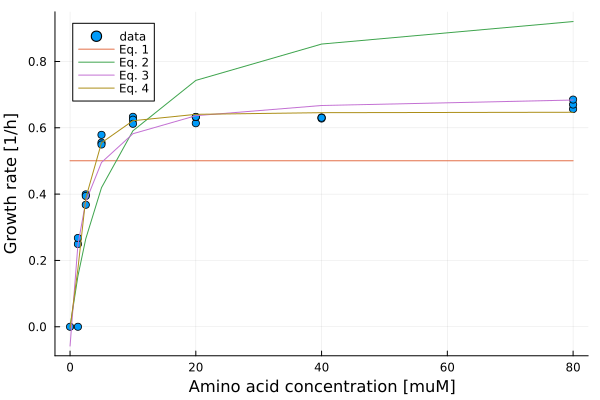

In [32]:
scatter(feature_matrix[:,2],res_first_seg_ML[7,2:end], label = "data",  xlabel = "Amino acid concentration [muM]", ylabel = "Growth rate [1/h]")
plot!(sort(feature_matrix[:,2]),sort(gr_sy_reg[3][:,1]), label = "Eq. 1", xlabel = "Amino acid concentration [muM]", ylabel = "Growth rate [1/h]")
plot!(sort(feature_matrix[:,2]),sort(gr_sy_reg[3][:,2]), label = "Eq. 2",  xlabel = "Amino acid concentration [muM]", ylabel = "Growth rate [1/h]")
plot!(sort(feature_matrix[:,2]),sort(gr_sy_reg[3][:,3]), label = "Eq. 3",  xlabel = "Amino acid concentration [muM]", ylabel = "Growth rate [1/h]")
display(plot!(sort(feature_matrix[:,2]),sort(gr_sy_reg[3][:,4]), label = "Eq. 4",  xlabel = "Amino acid concentration [muM]", ylabel = "Growth rate [1/h]"))

